In [13]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [14]:
# 1. 데이터 로드
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# 2. 클래스 이름 정의 (CIFAR-10 공식 순서)
classes = ['비행기', '자동차', '새', '고양이', '사슴', '개', '개구리', '말', '배', '트럭']

# 3. 데이터 차원 확인
print("==== 데이터 구조 확인 ====")
print(f"Train 이미지 차원: {x_train.shape}")  # (50000, 32, 32, 3) -> 5만장, 32x32 해상도, RGB 3채널
print(f"Train 라벨 차원: {y_train.shape}")    # (50000, 1)
print(f"Test 이미지 차원: {x_test.shape}")    # (10000, 32, 32, 3)
print(f"테스트 데이터 비율: {len(x_test) / (len(x_train) + len(x_test)) * 100:.1f}%")
print(f"픽셀 최솟값: {x_train.min()}, 최댓값: {x_train.max()}")

==== 데이터 구조 확인 ====
Train 이미지 차원: (50000, 32, 32, 3)
Train 라벨 차원: (50000, 1)
Test 이미지 차원: (10000, 32, 32, 3)
테스트 데이터 비율: 16.7%
픽셀 최솟값: 0, 최댓값: 255


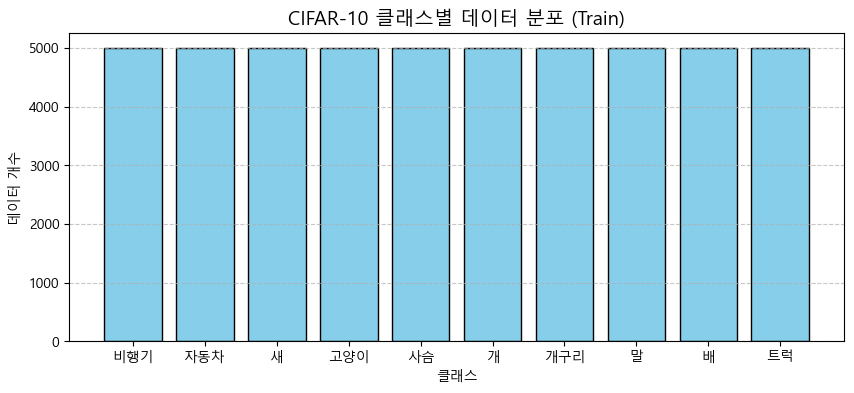

클래스별 개수: {'비행기': np.int64(5000), '자동차': np.int64(5000), '새': np.int64(5000), '고양이': np.int64(5000), '사슴': np.int64(5000), '개': np.int64(5000), '개구리': np.int64(5000), '말': np.int64(5000), '배': np.int64(5000), '트럭': np.int64(5000)}


In [15]:
import numpy as np

import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    # Windows 내장
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      # macOS
else:
    plt.rc('font', family='NanumGothic')      # Ubuntu: sudo apt install fonts-nanum

plt.rc('axes', unicode_minus=False)           # 마이너스 기호 깨짐 방지

# 클래스별 빈도수 계산
unique, counts = np.unique(y_train, return_counts=True)

# 시각화
plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title('CIFAR-10 클래스별 데이터 분포 (Train)', fontsize=14)
plt.xlabel('클래스')
plt.ylabel('데이터 개수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("클래스별 개수:", dict(zip(classes, counts)))

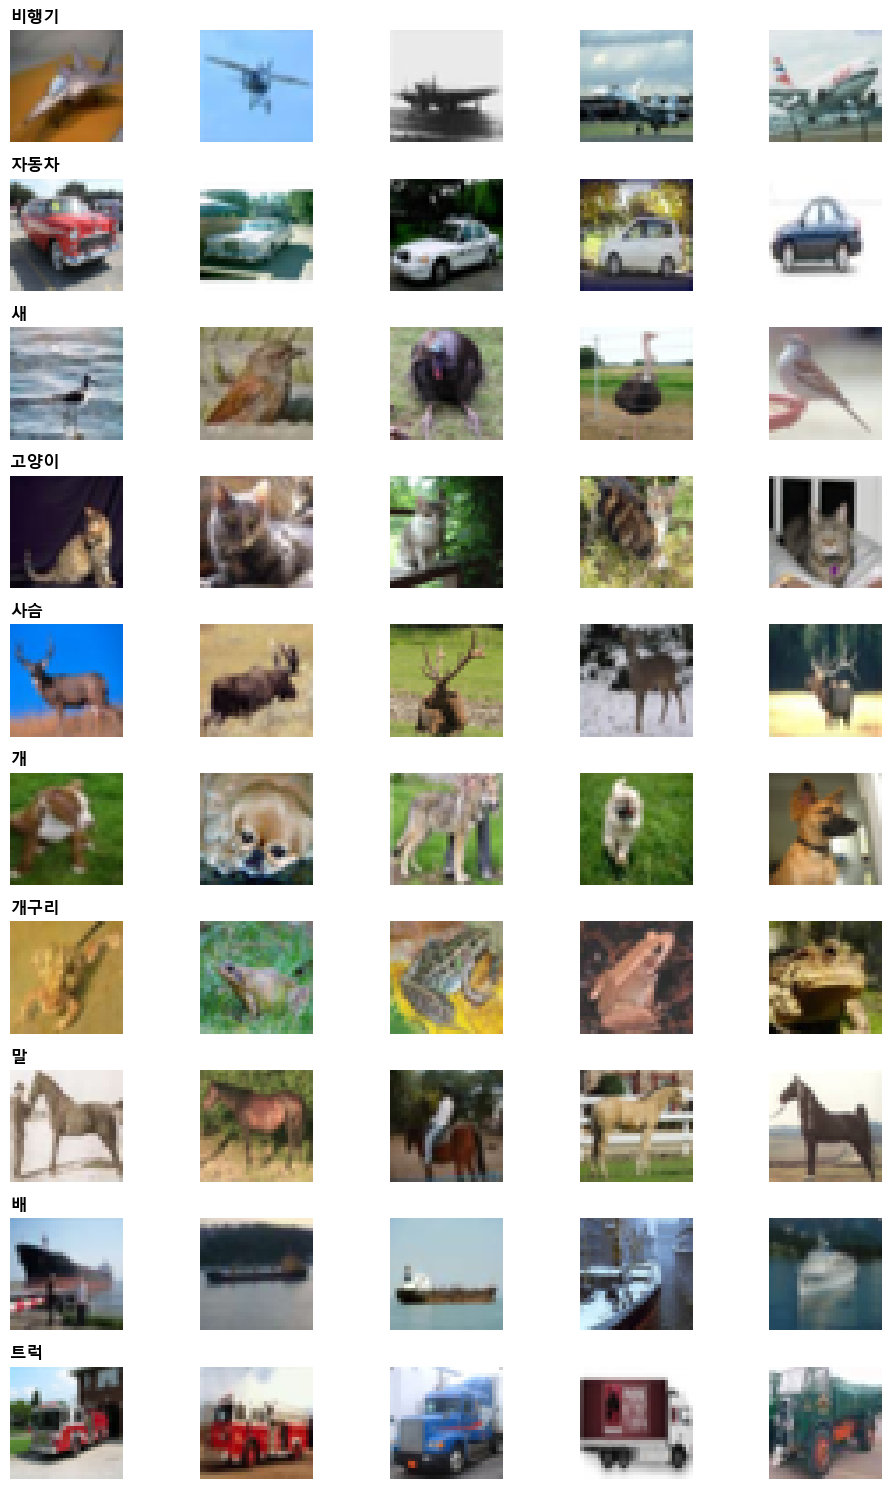

In [16]:
num_classes = 10
samples_per_class = 5

# 10행 5열의 서브플롯 생성
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 15))

for cluster_idx, class_name in enumerate(classes):
    # 해당 클래스의 인덱스만 추출
    idx = np.flatnonzero(y_train == cluster_idx)
    # 무작위로 5개 선택
    rand_idx = np.random.choice(idx, samples_per_class, replace=False)
    
    for i, img_idx in enumerate(rand_idx):
        ax = axes[cluster_idx, i]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        
        # 첫 번째 열에만 클래스 이름 표시
        if i == 0:
            ax.set_title(class_name, loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# 데이터 스케일링
# ※ CIFAR-10은 이미 (50000, 32, 32, 3) 구조이므로 reshape 없이 바로 255.0으로 나눠도 됩니다!
x_train_scale = x_train / 255.0
x_test_scaled = x_test / 255.0

# 데이터 분할
x_train_scaled, val_train_scaled, y_train, val_test = \
    train_test_split(x_train_scale, y_train, test_size=0.2)

In [18]:
# 모델 구성
model = keras.Sequential()
model.add(keras.layers.Input(shape=(32, 32, 3)))
model.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same'))
model.add(keras.layers.MaxPool2D())
model.add(keras.layers.Conv2D(64, 3, activation='relu', padding='same'))
model.add(keras.layers.MaxPool2D())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,102 (1.64 MB)

 Trainable params: 430,102 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=['accuracy'],
              jit_compile=False)

early_stopping = keras.callbacks.EarlyStopping(patience=2, 
                                               restore_best_weights=True)

# 모델 학습
history = model.fit(x_train_scaled, y_train, 
                    epochs=20, 
                    callbacks=[early_stopping], 
                    validation_data=(val_train_scaled, val_test))

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4306 - loss: 1.5720 - val_accuracy: 0.5329 - val_loss: 1.2689
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5636 - loss: 1.2311 - val_accuracy: 0.6318 - val_loss: 1.0343
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6066 - loss: 1.1059 - val_accuracy: 0.6338 - val_loss: 1.0384
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6378 - loss: 1.0331 - val_accuracy: 0.6539 - val_loss: 0.9817
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6598 - loss: 0.9638 - val_accuracy: 0.6599 - val_loss: 0.9716
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6804 - loss: 0.9060 - val_accuracy: 0.6755 - val_loss: 0.9153
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6953 - loss: 0.8627 - val_accuracy: 0.6858 - val_loss: 0.9029
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7078 - loss: 0.8220 - 

In [20]:
# 검증 데이터 평가
model.evaluate(val_train_scaled, val_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6899 - loss: 0.8889


[0.8889443278312683, 0.6898999810218811]

- Fashion MNIST와 달리 CIFAR-10 데이터셋은 컬러 이미지에 가변적인 배경과 형태로 난이도가 높아서 정확도가 낮음
- 현재 만든 모델의 용량이 너무 작아서 이 데이터셋의 복잡함을 다 담아내지 못함 (Underfitting)
- 레이어를 더 많이 쌓거나 필터 수를 늘리는 방법으로 정확도 올리기 가능